In [1]:
import numpy as np
import pandas as pd
import pickle

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from astroML.datasets import fetch_sdss_specgals
from sklearn.model_selection import train_test_split
from astroML.utils.decorators import pickle_results
from scipy.ndimage import uniform_filter

In [2]:
# Get the data
df = pd.DataFrame(fetch_sdss_specgals())

# Calculate the color indices
df['u-g'] = df['modelMag_u'] - df['modelMag_g']
df['g-r'] = df['modelMag_g'] - df['modelMag_r']
df['r-i'] = df['modelMag_r'] - df['modelMag_i']
df['i-z'] = df['modelMag_i'] - df['modelMag_z']

In [3]:
# Filtering Parameters
mag_err = 1
z_min = 0.02

# Filter the dataset
df_clean = df[
    (df['modelMagErr_u'] < mag_err) &
    (df['modelMagErr_g'] < mag_err) &
    (df['modelMagErr_r'] < mag_err) &
    (df['modelMagErr_i'] < mag_err) &
    (df['modelMagErr_z'] < mag_err) &
    (df['z'] > z_min)
]

# Define the X and y datasets
X = df_clean[['u-g', 'g-r', 'r-i', 'i-z']]
y = df_clean['z']

# Define the file path
file_path = f'data/dataset_clean.pkl'

# Using pickle to save the splits locally
@pickle_results(file_path)
def split_data(X_data, y_data):
    X_train, X_temp, y_train, y_temp = train_test_split(X_data, y_data, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    return X_train, X_val, X_test, y_train, y_val, y_test

# Run the function to generate and save the splits
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

# Save the full dataset (without splits)
with open('data/full_dataset_clean.pkl', 'wb') as file:
    pickle.dump(df_clean, file)

@pickle_results: using precomputed results from 'data/dataset_clean.pkl'


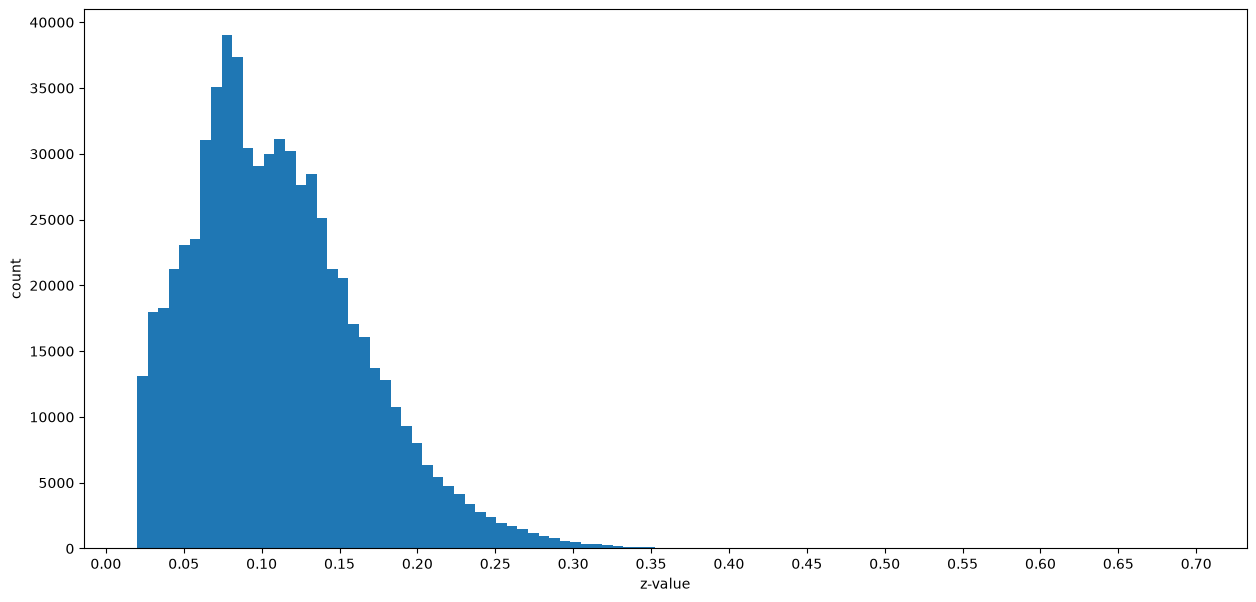

In [4]:
# --------------------
# Z-Value Distribution
# --------------------

# Create figure and axes objects
fig, ax = plt.subplots(figsize=(15,7))

# Plot the histogram
ax.hist(df['z'], bins=100)

# Force the x-axis to show a tick every 0.05 units
ax.xaxis.set_major_locator(MultipleLocator(0.05))

ax.set_xlabel("z-value")
ax.set_ylabel("count")
plt.show()

In [5]:
# ----------
# Finding Degenerate Regions (where similar colors correspond to realtively high variation in redshift)
# ----------
with open('data/full_dataset_clean.pkl', 'rb') as file:
    full_df = pickle.load(file)
g_r = full_df['g-r'].values
r_i = full_df['r-i'].values
z = full_df['z'].values

# Avoiding outliers in data
g_r_low, g_r_high = np.percentile(g_r, [1, 99])
r_i_low, r_i_high = np.percentile(r_i, [1, 99])

g_r_bins = np.linspace(g_r_low, g_r_high, 25)
r_i_bins = np.linspace(r_i_low, r_i_high, 25)

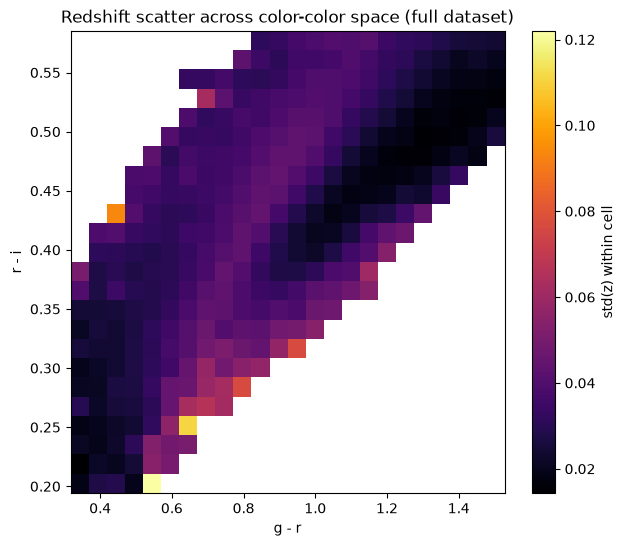

In [6]:
# Computer std(z) per cell of grid
z_std_cell = np.full((len(g_r_bins)-1, len(r_i_bins)-1), np.nan)
count_cell = np.zeros_like(z_std_cell)

# Building a 2D histogram and compute std(z) for each cell in grid
for i in range(len(g_r_bins) - 1):
    for j in range(len(r_i_bins) - 1):
        mask = (
            (g_r >= g_r_bins[i]) & (g_r < g_r_bins[i+1]) &
            (r_i >= r_i_bins[j]) & (r_i < r_i_bins[j+1])
        )
        n = mask.sum()
        count_cell[i,j] = n
        if(n >= 20):
            z_std_cell[i,j] = z[mask].std()
# Plot
plt.figure(figsize=(7, 6))
plt.imshow(z_std_cell.T, origin='lower', aspect='auto', cmap='inferno',
           extent=[g_r_bins[0], g_r_bins[-1], r_i_bins[0], r_i_bins[-1]])
plt.colorbar(label='std(z) within cell')
plt.xlabel('g - r')
plt.ylabel('r - i')
plt.title('Redshift scatter across color-color space (full dataset)')
plt.show()

In [8]:
# Search for a degenerate region
z_std_masked = np.where(count_cell >= 20, z_std_cell, np.nan)
z_std_smooth = uniform_filter(np.nan_to_num(z_std_masked), size=3)
valid_smooth = uniform_filter((count_cell >= 20).astype(float), size=3)
z_std_smooth = np.where(valid_smooth > 0.5, z_std_smooth / valid_smooth, np.nan)

# Top 5 cells
flat_sorted = np.argsort(np.nan_to_num(z_std_smooth, nan=-1).ravel())[::-1][:5]
for idx in flat_sorted:
    i, j = np.unravel_index(idx, z_std_smooth.shape)
    print(f"g-r [{g_r_bins[i]:.3f}, {g_r_bins[i+1]:.3f}]  r-i [{r_i_bins[j]:.3f}, {r_i_bins[j+1]:.3f}]  "
          f"std={z_std_smooth[i,j]:.4f}  N={int(count_cell[i,j])}")

g-r [0.671, 0.721]  r-i [0.243, 0.260]  std=0.0705  N=19
g-r [0.671, 0.721]  r-i [0.260, 0.276]  std=0.0670  N=43
g-r [0.721, 0.772]  r-i [0.260, 0.276]  std=0.0651  N=25
g-r [0.620, 0.671]  r-i [0.227, 0.243]  std=0.0632  N=27
g-r [0.570, 0.620]  r-i [0.211, 0.227]  std=0.0631  N=23


/var/folders/wd/xpr4pwmd0j5cfgtk9wrk8zdr0000gn/T/ipykernel_26002/2495001313.py:5: RuntimeWarning: invalid value encountered in divide
  z_std_smooth = np.where(valid_smooth > 0.5, z_std_smooth / valid_smooth, np.nan)
